In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test  = pd.read_csv("y_test.csv").values.ravel()

## Preprocessing (repeated from Logistic Regression)

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## XGBoost

In [4]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb)
])

In [5]:
xgb_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'log_annual_inc'],
      dtype='obje...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=5,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=600, n_jobs=-1,
                               num_parallel_tree=None, random_state=42, ...))])

In [6]:
from sklearn.metrics import roc_auc_score

train_probs = xgb_clf.predict_proba(X_train)[:, 1]
test_probs  = xgb_clf.predict_proba(X_test)[:, 1]

print("Train AUC:", round(roc_auc_score(y_train, train_probs), 4))
print("Test AUC :", round(roc_auc_score(y_test, test_probs), 4))

Train AUC: 0.7212
Test AUC : 0.71


In [13]:
import json
from datetime import datetime

xgb_metrics = {
    "model": "XGBoost",
    "train_auc": round(roc_auc_score(y_train, train_probs), 4),
    "test_auc": round(roc_auc_score(y_test, test_probs), 4),
    "validation_split": "Train: ≤2016 | Test: ≥2017",
    "timestamp": datetime.now().isoformat()
}

with open("../public/xgboost_metrics.json", "w") as f:
    json.dump(xgb_metrics, f, indent=4)

print("Saved xgboost_metrics.json")

Saved xgboost_metrics.json


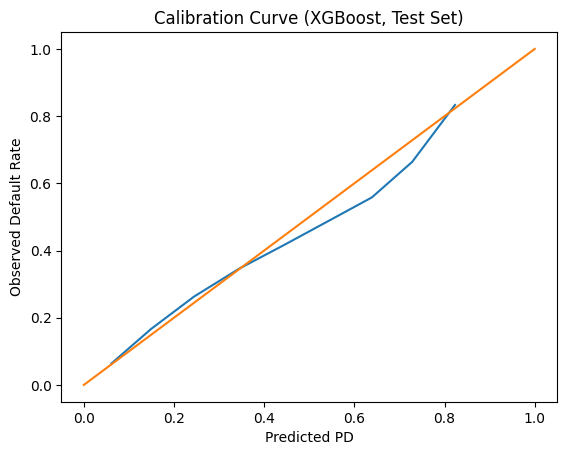

In [11]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true)
plt.plot([0, 1], [0, 1])
plt.xlabel("Predicted PD")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve (XGBoost, Test Set)")
plt.savefig("../public/calibration_curve_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

## Important Features 

In [8]:
import numpy as np

ohe = xgb_clf.named_steps["preprocessor"] \
            .named_transformers_["cat"] \
            .named_steps["encoder"]

cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_feature_names])

booster = xgb_clf.named_steps["model"]
importances = booster.feature_importances_

imp_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
            .sort_values("importance", ascending=False))

imp_df.head(20)

,feature,importance
2,int_rate,0.260929
1,term,0.248902
29,home_ownership_MORTGAGE,0.088527
33,home_ownership_RENT,0.081146
5,dti,0.040313
7,inq_last_6mths,0.022377
13,log_annual_inc,0.021934
9,pub_rec,0.021250
0,loan_amnt,0.017115
3,installment,0.016224


In [9]:
import joblib

joblib.dump(xgb_clf, "xgb_champion_model.pkl")

['xgb_champion_model.pkl']

# Model Comparison – Logistic Regression vs XGBoost

## Discriminatory Power (AUC)

| Model | Train AUC | Test AUC |
|--------|----------|----------|
| Logistic Regression | 0.7061 | 0.6965 |
| XGBoost | 0.7212 | 0.7100 |

XGBoost improves forward test AUC by approximately 1.3 percentage points relative to logistic regression, indicating stronger discriminatory power while maintaining similar generalization gap.

---

## Calibration

- Logistic regression shows good calibration up to moderate predicted PD levels, but tends to overestimate risk in the high-PD region.
- XGBoost exhibits better alignment with observed default rates across most probability ranges, with only minor overestimation above ~0.7 PD.

Overall, XGBoost provides both improved ranking performance and improved probability calibration.

---

## Feature Importance and Economic Consistency

Both models produce economically coherent risk drivers:

- Higher credit grade → lower default risk  
- Higher DTI and revolving utilization → higher risk  
- Higher income and longer employment → lower risk  

XGBoost places strong importance on internal credit grade and loan term, suggesting nonlinear structure within grade segments.

---

## Conclusion

XGBoost outperforms logistic regression in forward discrimination and calibration, with no significant overfitting. It is therefore selected as the Champion model for subsequent decision analysis.